In [3]:
import streamlit as st
import pandas as pd
from IPython.core.pylabtools import figsize
from matplotlib import pyplot as plt

In [4]:
df = pd.read_csv('data/data.csv', encoding='euc_kr')

In [5]:
df.head()

,항구청코드,입출항구분,호출부호,입항년도,입항횟수,신고일시,계선시설명,적재화물명,적재톤수,환적톤수,...,입출항일시,입항목적명,전출항지국가명,전출항지항구명,차항지국가명,차항지항구명,목적지국가명,목적지항구명,등록일시,수정일시
0,여천,입항,H3VB,2025,1,2025-05-30 13:48:04,W구역,해당없음,0.0,0.0,...,2025-03-21 02:06:00,적하,중국,NINGBO,일본,MIZUSHIMA,NaN,NaN,2025-05-27 09:16:54,2025-06-02 10:35:58
1,부산,입항,D7SS,2025,1,2025-05-16 10:19:56,동일조선안벽-02,해당없음,0.0,0.0,...,2025-05-02 13:35:00,선박수리,일본,"NAGOYA, AICHI",대한민국,광양,NaN,NaN,2025-05-16 10:07:54,2025-05-19 09:52:11
2,부산,입항,D7SS,2025,1,2025-05-16 10:19:56,동일조선안벽-02,해당없음,0.0,0.0,...,2025-05-02 13:35:00,선박수리,일본,"NAGOYA, AICHI",대한민국,광양,NaN,NaN,2025-05-16 10:07:54,2025-05-19 09:52:11
3,부산,입항,D7SS,2025,1,2025-05-16 10:19:56,동일조선안벽-02,해당없음,0.0,0.0,...,2025-05-02 13:35:00,선박수리,일본,"NAGOYA, AICHI",대한민국,광양,NaN,NaN,2025-05-16 10:07:54,2025-05-19 09:52:10
4,부산,입항,D7SS,2025,1,2025-05-16 10:19:56,동일조선안벽-02,해당없음,0.0,0.0,...,2025-05-02 13:35:00,선박수리,일본,"NAGOYA, AICHI",대한민국,광양,NaN,NaN,2025-05-16 10:07:54,2025-05-20 09:51:13


In [6]:
df.shape


(24068, 28)

In [7]:
df.isna().sum()

항구청코드          0
입출항구분          0
호출부호           0
입항년도           0
입항횟수           0
신고일시           0
계선시설명          4
적재화물명          0
적재톤수           0
환적톤수           0
양적하화물톤         0
위험물톤수          0
징수결정톤수         0
총톤수            0
내외항구분          0
선박국적명          0
선박종류명          0
선박명            0
입출항일시          0
입항목적명      10325
전출항지국가명    10327
전출항지항구명    10327
차항지국가명         4
차항지항구명         4
목적지국가명     13745
목적지항구명     13745
등록일시           0
수정일시           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(1654)

In [9]:
dt = df.drop_duplicates()
dt.shape

(22414, 28)

In [9]:
dt.columns

Index(['항구청코드', '입출항구분', '호출부호', '입항년도', '입항횟수', '신고일시', '계선시설명', '적재화물명',
       '적재톤수', '환적톤수', '양적하화물톤', '위험물톤수', '징수결정톤수', '총톤수', '내외항구분', '선박국적명',
       '선박종류명', '선박명', '입출항일시', '입항목적명', '전출항지국가명', '전출항지항구명', '차항지국가명',
       '차항지항구명', '목적지국가명', '목적지항구명', '등록일시', '수정일시'],
      dtype='str')

In [13]:
dt['항구청코드'].value_counts()

항구청코드
부산      7366
울산      3547
인천      2362
광양      1849
평택      1535
여천      1409
여수      1032
대산       785
군산       543
포항신항     426
마산       419
통영       370
동해       120
서귀포      114
대불분실     112
제주        95
고현        81
옥포        39
진해        38
장항        37
영일만항      36
경인        24
목포        22
묵호        15
보령        11
옥계         7
속초         5
용기포        4
당진화력       3
삼천포        3
완도         2
호산         1
태안         1
하동         1
Name: count, dtype: int64

In [14]:
result = dt.groupby('항구청코드')['양적하화물톤'].sum().sort_values(ascending=False)
print(result.apply(lambda x: f"{x:,.0f}"))

항구청코드
부산      35,828,945
울산      10,119,559
인천       5,839,343
여천       5,826,818
광양       4,708,250
평택       3,988,375
대산       2,110,194
포항신항     1,107,405
군산         988,387
동해         440,465
마산         371,795
보령         193,458
대불분실       182,773
태안         160,424
고현          88,978
영일만항        81,131
옥포          75,290
장항          73,374
진해          59,464
묵호          50,741
경인          44,868
목포           4,036
통영           3,149
제주           1,000
삼천포            244
속초             219
여수               0
서귀포              0
당진화력             0
옥계               0
용기포              0
완도               0
하동               0
호산               0
Name: 양적하화물톤, dtype: str


In [15]:
dt['선박종류명'].value_counts()

선박종류명
풀컨테이너선         7149
일반화물선          4112
석유제품 운반선       2499
케미칼 운반선        1594
산물선(벌크선)       1536
국제카페리          1240
LPG 운반선        1186
여객선             597
자동차운반선          564
원양 어선           494
세미(혼재)컨테이너선     343
크루즈선            305
냉동.냉장선          235
원유운반선           143
케미칼가스 운반선        80
시멘트운반선           65
견인용예선            55
기타선              50
LNG 운반선          50
기타 예선            43
관공선              22
수상레저기구           20
철강재 운반선          14
군함               10
기타 유조선            6
연근해 어선            1
이.접안용 예선          1
Name: count, dtype: int64

In [16]:
result = dt[dt['항구청코드'].isin(['부산','울산','인천'])].groupby('항구청코드')['선박종류명'].value_counts()
print(result)

항구청코드  선박종류명      
부산     풀컨테이너선         4429
       일반화물선           704
       여객선             595
       산물선(벌크선)        370
       국제카페리           245
       냉동.냉장선          207
       원양 어선           164
       세미(혼재)컨테이너선     151
       석유제품 운반선        144
       케미칼 운반선         101
       크루즈선             96
       자동차운반선           51
       LPG 운반선          24
       원유운반선            21
       시멘트운반선           20
       기타 예선            11
       기타선              10
       관공선               7
       견인용예선             7
       LNG 운반선           5
       군함                2
       기타 유조선            1
       이.접안용 예선          1
울산     석유제품 운반선       1386
       케미칼 운반선         926
       일반화물선           445
       풀컨테이너선          301
       LPG 운반선         216
       산물선(벌크선)        142
       자동차운반선           64
       원유운반선            49
       케미칼가스 운반선         5
       크루즈선              5
       기타선               3
       기타 유조선            2
       세미(혼재)컨테이너선       2
       냉동

In [17]:
danger = dt.groupby('항구청코드')['위험물톤수'].sum().sort_values(ascending=False)
print(danger)


항구청코드
울산      9522555.344
여천      6837125.485
대산      2647527.020
여수      1304954.126
부산      1244667.540
인천       896320.660
평택       366260.000
보령       211745.788
광양       118325.934
군산        24382.000
동해        17000.000
고현         1428.000
마산          586.800
경인            0.000
삼천포           0.000
목포            0.000
당진화력          0.000
대불분실          0.000
서귀포           0.000
속초            0.000
묵호            0.000
영일만항          0.000
완도            0.000
옥포            0.000
용기포           0.000
옥계            0.000
장항            0.000
제주            0.000
태안            0.000
진해            0.000
통영            0.000
포항신항          0.000
하동            0.000
호산            0.000
Name: 위험물톤수, dtype: float64


In [18]:
yeocheon = dt[dt['항구청코드']=='대산']
yeocheon['선박종류명'].value_counts()

선박종류명
LPG 운반선      297
석유제품 운반선     230
케미칼 운반선      125
풀컨테이너선        46
일반화물선         37
케미칼가스 운반선     29
원유운반선         16
산물선(벌크선)       5
Name: count, dtype: int64

In [19]:
dt['차항지국가명'].value_counts()

차항지국가명
중국           10390
일본            7093
대한민국          2479
원양어획지역         797
러시아            339
미국             260
싱가포르           232
대만             122
멕시코            122
캐나다            101
호주              79
베트남             73
파나마             57
필리핀             53
인도네시아           27
홍콩              27
말레이시아           21
인도              19
태국              16
콜롬비아            13
페루              13
칠레              10
파푸아 뉴기니          8
뉴질랜드             8
이탈리아             5
바누아투             4
자메이카             4
가이아나             3
요르단              3
브라질              3
미크로네시아           3
알제리              2
방글라데시            2
마샬 제도            2
괌                2
모리셔스             2
니카라과             2
캄보디아             2
과테말라             1
나미비아             1
카타르              1
아르헨티나            1
온두라스             1
터키               1
슬로베니아            1
뉴칼레도니아           1
가나               1
남아프리카            1
아랍에미리트연합국        1
나우루              1
Name: count, dtype: int64

In [20]:
china = dt[dt['차항지국가명'] =='중국']
china['차항지항구명'].value_counts()

차항지항구명
SHANGHAI       1130
QINGDAO        1014
NINGBO          809
DALIAN          668
LIANYUNGANG     427
               ... 
LIUZHOU           1
ZHENHAI PT        1
XIANING           1
DANZHOU           1
DANTOU            1
Name: count, Length: 138, dtype: int64

In [21]:
japan = dt[dt['차항지국가명'] =='일본']
japan['차항지항구명'].value_counts()

차항지항구명
OSAKA             385
HITAKATSU         383
SHIMONOSEKI       378
HAKATA/FUKUOKA    355
YOKOHAMA          268
                 ... 
MIKAWA              1
TADOTSU             1
IMABARI             1
JAPAN ODAIBA        1
MITSUKOSHIMA        1
Name: count, Length: 193, dtype: int64

In [22]:
korea = dt[dt['차항지국가명'] =='대한민국']
korea['차항지항구명'].value_counts()

차항지항구명
광양       587
울산       433
부산       392
인천       221
평택.당진    129
여수       124
대산       101
군산        68
포항신항      62
부산 신항     57
마산        57
기타항       45
포항        35
통영        27
목포        26
여천항       24
당진        19
동해        17
제주        14
온산        10
영일만항       6
옥계항        6
삼척         5
서귀포        4
장승포        2
장항         2
묵호         2
옥포         1
진해         1
고현         1
속초         1
Name: count, dtype: int64

In [23]:
dt.head(3)

,항구청코드,입출항구분,호출부호,입항년도,입항횟수,신고일시,계선시설명,적재화물명,적재톤수,환적톤수,...,입출항일시,입항목적명,전출항지국가명,전출항지항구명,차항지국가명,차항지항구명,목적지국가명,목적지항구명,등록일시,수정일시
0,여천,입항,H3VB,2025,1,2025-05-30 13:48:04,W구역,해당없음,0.0,0.0,...,2025-03-21 02:06:00,적하,중국,NINGBO,일본,MIZUSHIMA,NaN,NaN,2025-05-27 09:16:54,2025-06-02 10:35:58
1,부산,입항,D7SS,2025,1,2025-05-16 10:19:56,동일조선안벽-02,해당없음,0.0,0.0,...,2025-05-02 13:35:00,선박수리,일본,"NAGOYA, AICHI",대한민국,광양,NaN,NaN,2025-05-16 10:07:54,2025-05-19 09:52:11
3,부산,입항,D7SS,2025,1,2025-05-16 10:19:56,동일조선안벽-02,해당없음,0.0,0.0,...,2025-05-02 13:35:00,선박수리,일본,"NAGOYA, AICHI",대한민국,광양,NaN,NaN,2025-05-16 10:07:54,2025-05-19 09:52:10


In [24]:
dt['항만별 입출항 총수'] = dt.groupby('항구청코드')['항구청코드'].transform('count')
df

,항구청코드,입출항구분,호출부호,입항년도,입항횟수,신고일시,계선시설명,적재화물명,적재톤수,환적톤수,...,입출항일시,입항목적명,전출항지국가명,전출항지항구명,차항지국가명,차항지항구명,목적지국가명,목적지항구명,등록일시,수정일시
0,여천,입항,H3VB,2025,1,2025-05-30 13:48:04,W구역,해당없음,0.0,0.0,...,2025-03-21 02:06:00,적하,중국,NINGBO,일본,MIZUSHIMA,NaN,NaN,2025-05-27 09:16:54,2025-06-02 10:35:58
1,부산,입항,D7SS,2025,1,2025-05-16 10:19:56,동일조선안벽-02,해당없음,0.0,0.0,...,2025-05-02 13:35:00,선박수리,일본,"NAGOYA, AICHI",대한민국,광양,NaN,NaN,2025-05-16 10:07:54,2025-05-19 09:52:11
2,부산,입항,D7SS,2025,1,2025-05-16 10:19:56,동일조선안벽-02,해당없음,0.0,0.0,...,2025-05-02 13:35:00,선박수리,일본,"NAGOYA, AICHI",대한민국,광양,NaN,NaN,2025-05-16 10:07:54,2025-05-19 09:52:11
3,부산,입항,D7SS,2025,1,2025-05-16 10:19:56,동일조선안벽-02,해당없음,0.0,0.0,...,2025-05-02 13:35:00,선박수리,일본,"NAGOYA, AICHI",대한민국,광양,NaN,NaN,2025-05-16 10:07:54,2025-05-19 09:52:10
4,부산,입항,D7SS,2025,1,2025-05-16 10:19:56,동일조선안벽-02,해당없음,0.0,0.0,...,2025-05-02 13:35:00,선박수리,일본,"NAGOYA, AICHI",대한민국,광양,NaN,NaN,2025-05-16 10:07:54,2025-05-20 09:51:13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24063,부산,출항,H3SY,2025,27,2025-08-12 08:23:47,신항 6부두 3선석,잡품,6019.0,0.0,...,2025-08-11 08:38:00,NaN,NaN,NaN,중국,TIANJIN XINGANG PT,중국,TIANJIN XINGANG PT,2025-07-30 15:05:04,2025-08-12 08:32:52
24064,부산,입항,VRSS8,2025,23,2025-08-12 08:24:33,감만부두 3선석,잡품,2021.0,1153.0,...,2025-08-12 00:33:00,양적하,대한민국,울산,일본,SHIMIZU,NaN,NaN,2025-07-30 15:12:40,2025-08-12 10:56:43
24065,부산,입항,H8BZ,2025,14,2025-08-12 08:25:38,감만부두 1선석,잡품,6162.0,1658.0,...,2025-08-12 00:35:00,양적하,중국,FUQING,대한민국,광양,NaN,NaN,2025-07-30 15:54:42,2025-08-13 08:29:17
24066,부산,출항,VRSS8,2025,23,2025-08-12 10:49:14,감만부두 3선석,잡품,2461.0,0.0,...,2025-08-12 08:52:00,NaN,NaN,NaN,일본,SHIMIZU,일본,SHIMIZU,2025-07-30 15:12:41,2025-08-12 10:56:48


In [25]:
dt['항만별 화물 처리량(톤)'] = dt.groupby('항구청코드')['양적하화물톤'].transform('sum')
dt

dt['항만별 화물 처리량(톤)_표시'] = dt['항만별 화물 처리량(톤)'].apply(lambda x: f"{x:,.0f}")
dt

,항구청코드,입출항구분,호출부호,입항년도,입항횟수,신고일시,계선시설명,적재화물명,적재톤수,환적톤수,...,전출항지항구명,차항지국가명,차항지항구명,목적지국가명,목적지항구명,등록일시,수정일시,항만별 입출항 총수,항만별 화물 처리량(톤),항만별 화물 처리량(톤)_표시
0,여천,입항,H3VB,2025,1,2025-05-30 13:48:04,W구역,해당없음,0.0,0.0,...,NINGBO,일본,MIZUSHIMA,NaN,NaN,2025-05-27 09:16:54,2025-06-02 10:35:58,1409,5.826818e+06,"5,826,818"
1,부산,입항,D7SS,2025,1,2025-05-16 10:19:56,동일조선안벽-02,해당없음,0.0,0.0,...,"NAGOYA, AICHI",대한민국,광양,NaN,NaN,2025-05-16 10:07:54,2025-05-19 09:52:11,7366,3.582894e+07,"35,828,945"
3,부산,입항,D7SS,2025,1,2025-05-16 10:19:56,동일조선안벽-02,해당없음,0.0,0.0,...,"NAGOYA, AICHI",대한민국,광양,NaN,NaN,2025-05-16 10:07:54,2025-05-19 09:52:10,7366,3.582894e+07,"35,828,945"
4,부산,입항,D7SS,2025,1,2025-05-16 10:19:56,동일조선안벽-02,해당없음,0.0,0.0,...,"NAGOYA, AICHI",대한민국,광양,NaN,NaN,2025-05-16 10:07:54,2025-05-20 09:51:13,7366,3.582894e+07,"35,828,945"
7,여수,출항,9LU2431,2025,1,2025-05-13 10:33:05,정박지W구역(A4),해당없음,0.0,0.0,...,NaN,중국,LANSHAN PT,원양어획지역,OCEAN DISTRICT,2025-05-13 10:28:19,2025-05-13 10:38:23,1032,0.000000e+00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24063,부산,출항,H3SY,2025,27,2025-08-12 08:23:47,신항 6부두 3선석,잡품,6019.0,0.0,...,NaN,중국,TIANJIN XINGANG PT,중국,TIANJIN XINGANG PT,2025-07-30 15:05:04,2025-08-12 08:32:52,7366,3.582894e+07,"35,828,945"
24064,부산,입항,VRSS8,2025,23,2025-08-12 08:24:33,감만부두 3선석,잡품,2021.0,1153.0,...,울산,일본,SHIMIZU,NaN,NaN,2025-07-30 15:12:40,2025-08-12 10:56:43,7366,3.582894e+07,"35,828,945"
24065,부산,입항,H8BZ,2025,14,2025-08-12 08:25:38,감만부두 1선석,잡품,6162.0,1658.0,...,FUQING,대한민국,광양,NaN,NaN,2025-07-30 15:54:42,2025-08-13 08:29:17,7366,3.582894e+07,"35,828,945"
24066,부산,출항,VRSS8,2025,23,2025-08-12 10:49:14,감만부두 3선석,잡품,2461.0,0.0,...,NaN,일본,SHIMIZU,일본,SHIMIZU,2025-07-30 15:12:41,2025-08-12 10:56:48,7366,3.582894e+07,"35,828,945"


In [26]:
df['항만별 위험물 처리량(톤)'] = dt.groupby('항구청코드')['위험물톤수'].transform('sum')
dt

,항구청코드,입출항구분,호출부호,입항년도,입항횟수,신고일시,계선시설명,적재화물명,적재톤수,환적톤수,...,전출항지항구명,차항지국가명,차항지항구명,목적지국가명,목적지항구명,등록일시,수정일시,항만별 입출항 총수,항만별 화물 처리량(톤),항만별 화물 처리량(톤)_표시
0,여천,입항,H3VB,2025,1,2025-05-30 13:48:04,W구역,해당없음,0.0,0.0,...,NINGBO,일본,MIZUSHIMA,NaN,NaN,2025-05-27 09:16:54,2025-06-02 10:35:58,1409,5.826818e+06,"5,826,818"
1,부산,입항,D7SS,2025,1,2025-05-16 10:19:56,동일조선안벽-02,해당없음,0.0,0.0,...,"NAGOYA, AICHI",대한민국,광양,NaN,NaN,2025-05-16 10:07:54,2025-05-19 09:52:11,7366,3.582894e+07,"35,828,945"
3,부산,입항,D7SS,2025,1,2025-05-16 10:19:56,동일조선안벽-02,해당없음,0.0,0.0,...,"NAGOYA, AICHI",대한민국,광양,NaN,NaN,2025-05-16 10:07:54,2025-05-19 09:52:10,7366,3.582894e+07,"35,828,945"
4,부산,입항,D7SS,2025,1,2025-05-16 10:19:56,동일조선안벽-02,해당없음,0.0,0.0,...,"NAGOYA, AICHI",대한민국,광양,NaN,NaN,2025-05-16 10:07:54,2025-05-20 09:51:13,7366,3.582894e+07,"35,828,945"
7,여수,출항,9LU2431,2025,1,2025-05-13 10:33:05,정박지W구역(A4),해당없음,0.0,0.0,...,NaN,중국,LANSHAN PT,원양어획지역,OCEAN DISTRICT,2025-05-13 10:28:19,2025-05-13 10:38:23,1032,0.000000e+00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24063,부산,출항,H3SY,2025,27,2025-08-12 08:23:47,신항 6부두 3선석,잡품,6019.0,0.0,...,NaN,중국,TIANJIN XINGANG PT,중국,TIANJIN XINGANG PT,2025-07-30 15:05:04,2025-08-12 08:32:52,7366,3.582894e+07,"35,828,945"
24064,부산,입항,VRSS8,2025,23,2025-08-12 08:24:33,감만부두 3선석,잡품,2021.0,1153.0,...,울산,일본,SHIMIZU,NaN,NaN,2025-07-30 15:12:40,2025-08-12 10:56:43,7366,3.582894e+07,"35,828,945"
24065,부산,입항,H8BZ,2025,14,2025-08-12 08:25:38,감만부두 1선석,잡품,6162.0,1658.0,...,FUQING,대한민국,광양,NaN,NaN,2025-07-30 15:54:42,2025-08-13 08:29:17,7366,3.582894e+07,"35,828,945"
24066,부산,출항,VRSS8,2025,23,2025-08-12 10:49:14,감만부두 3선석,잡품,2461.0,0.0,...,NaN,일본,SHIMIZU,일본,SHIMIZU,2025-07-30 15:12:41,2025-08-12 10:56:48,7366,3.582894e+07,"35,828,945"


In [27]:
dt.dtypes

항구청코드                   str
입출항구분                   str
호출부호                    str
입항년도                  int64
입항횟수                  int64
신고일시                    str
계선시설명                   str
적재화물명                   str
적재톤수                float64
환적톤수                float64
양적하화물톤              float64
위험물톤수               float64
징수결정톤수                int64
총톤수                 float64
내외항구분                   str
선박국적명                   str
선박종류명                   str
선박명                     str
입출항일시                   str
입항목적명                   str
전출항지국가명                 str
전출항지항구명                 str
차항지국가명                  str
차항지항구명                  str
목적지국가명                  str
목적지항구명                  str
등록일시                    str
수정일시                    str
항만별 입출항 총수            int64
항만별 화물 처리량(톤)       float64
항만별 화물 처리량(톤)_표시        str
dtype: object

In [43]:
print(dt.columns)

Index(['항구청코드', '입출항구분', '호출부호', '입항년도', '입항횟수', '신고일시', '계선시설명', '적재화물명',
       '적재톤수', '환적톤수', '양적하화물톤', '위험물톤수', '징수결정톤수', '총톤수', '내외항구분', '선박국적명',
       '선박종류명', '선박명', '입출항일시', '입항목적명', '전출항지국가명', '전출항지항구명', '차항지국가명',
       '차항지항구명', '목적지국가명', '목적지항구명', '등록일시', '수정일시', '항만별 입출항 총수',
       '항만별 화물 처리량(톤)', '항만별 화물 처리량(톤)_표시'],
      dtype='str')


In [37]:
dt['항만별 화물 처리량(톤)_표시'] = dt['항만별 화물 처리량(톤)'].astype(int)


cols = ['항만별 입출항 총수','항만별 화물 처리량(톤)_표시', '항만별 위험물 처리량(톤)']

corr = dt[cols].corr()

corr

KeyError: "['항만별 위험물 처리량(톤)'] not in index"

In [44]:
import plotly.express as px

NameError: name 'px' is not defined

In [38]:
fig = px.imshow(corr, text_auto=True, aspect='auto', title='주요 KPI의 상관관계')

fig.show()

NameError: name 'px' is not defined

## 징수결정톤수 알아보기
징수결정톤수: 항만이 요금이나 사용료를 게산할 때 기준으로 잡는 선박의 톤수

In [31]:
charge_ton = (
    dt.groupby('항구청코드')['징수결정톤수'].sum().sort_values(ascending=False)
)

print(charge_ton.apply(lambda x: f'{x:,.0f}'))

항구청코드
부산      218,608,587
인천       43,615,937
광양       40,604,897
울산       36,368,713
여수       27,702,302
평택       26,900,252
여천       13,502,337
서귀포      11,307,849
군산        9,874,007
마산        8,750,548
대산        7,340,703
제주        6,208,641
포항신항      2,785,840
대불분실      2,538,137
동해        1,580,681
옥포        1,305,120
고현        1,044,475
보령          755,632
영일만항        456,462
당진화력        244,628
옥계          183,344
통영          153,445
장항          121,466
경인          121,247
호산          114,181
진해           96,913
태안           91,178
속초           70,020
묵호           59,593
삼천포          47,061
하동           38,888
목포           37,692
용기포           8,392
완도            1,996
Name: 징수결정톤수, dtype: str


In [32]:
port_compare = dt.groupby('항구청코드').agg(
    입출항수=('항구청코드', 'size'),
    총톤수=('총톤수', 'sum'),
    화물처리량=('양적하화물톤', 'sum'),
    징수결정톤수=('징수결정톤수', 'sum')
)
port_compare = port_compare.sort_values(
    '징수결정톤수',
    ascending=False
)

port_compare.head(10)

,입출항수,총톤수,화물처리량,징수결정톤수
항구청코드,,,,
부산,7366,2.182442e+08,3.582894e+07,218608587
인천,2362,4.361851e+07,5.839343e+06,43615937
광양,1849,4.060490e+07,4.708250e+06,40604897
울산,3547,3.636871e+07,1.011956e+07,36368713
여수,1032,2.770230e+07,0.000000e+00,27702302
평택,1535,2.690025e+07,3.988375e+06,26900252
여천,1409,1.350234e+07,5.826818e+06,13502337
서귀포,114,1.130785e+07,0.000000e+00,11307849
군산,543,9.263951e+06,9.883873e+05,9874007


## 입출항 1건당 징수결정톤수
- 힌 척 들어올 때 평균적으로 얼마나 큰가

In [16]:
port_compare['건당_징수결정톤수'] = (
    port_compare['징수결정톤수']
    / port_compare['입출항수']
)

port_compare.sort_values(
    '건당_징수결정톤수',
    ascending=False
).head(10)


,입출항수,총톤수,화물처리량,징수결정톤수,건당_징수결정톤수
항구청코드,,,,,
호산,1,114181.0,0.000000e+00,114181,114181.000000
서귀포,114,11307849.0,0.000000e+00,11307849,99191.657895
태안,1,91178.0,1.604240e+05,91178,91178.000000
당진화력,3,244628.0,0.000000e+00,244628,81542.666667
보령,11,755632.0,1.934575e+05,755632,68693.818182
제주,95,6208641.0,1.000000e+03,6208641,65354.115789
하동,1,38888.0,0.000000e+00,38888,38888.000000
옥포,39,1294930.0,7.528984e+04,1305120,33464.615385
부산,7366,218244201.0,3.582894e+07,218608587,29678.059598


- 징수결정톤수가 총톤수와 거의 같게 움직이는 항만이 많다.

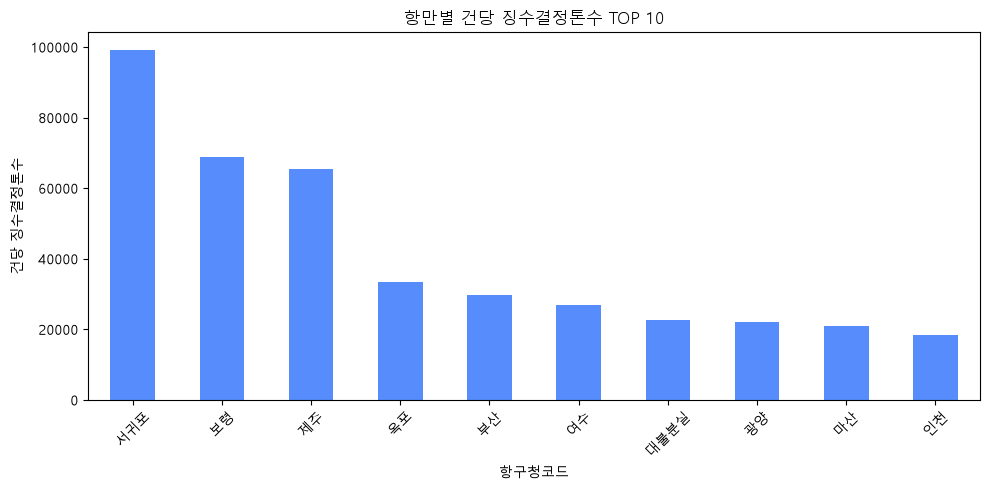

In [29]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

filtered_port = port_compare[
    port_compare['입출항수'] >= 10
]

top10 = filtered_port.sort_values(
    '건당_징수결정톤수',
    ascending=False
).head(10)

top10['건당_징수결정톤수'].plot(
    kind='bar',
    figsize=(10, 5),
)

plt.title('항만별 건당 징수결정톤수 TOP 10')
plt.xlabel('항구청코드')
plt.ylabel('건당 징수결정톤수')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [11]:
top3 = dt[
    dt['항구청코드'].isin(['부산', '울산', '인천'])
]

port_summary = top3.groupby('항구청코드').agg(
    입출항수=('항구청코드', 'size'),
    화물처리량=('양적하화물톤', 'sum'),
).reset_index()

port_summary

,항구청코드,입출항수,화물처리량
0,부산,7366,3.582894e+07
1,울산,3547,1.011956e+07
2,인천,2362,5.839343e+06


In [46]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

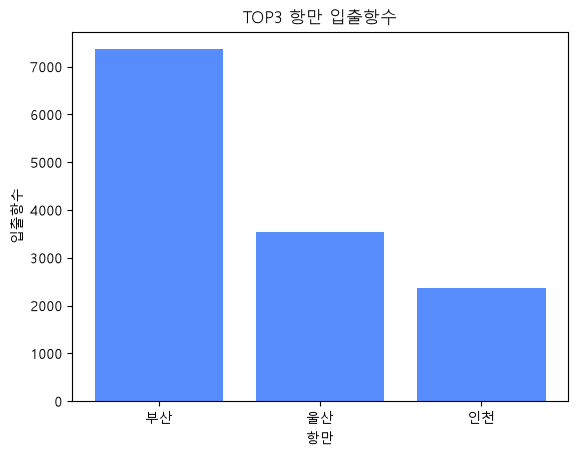

In [47]:
top3 = dt[dt['항구청코드'].isin(['부산', '울산', '인천'])]

plt.bar(
    top3['항구청코드'],
    top3['항만별 입출항 총수']
)

plt.title('TOP3 항만 입출항수')
plt.xlabel('항만')
plt.ylabel('입출항수')

plt.show()

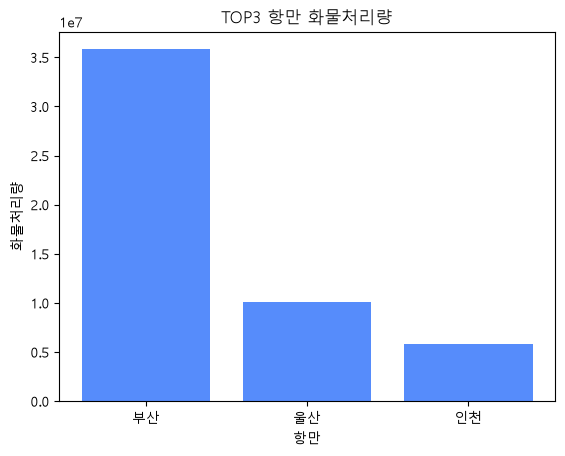

In [48]:
plt.bar(
    top3['항구청코드'],
    top3['항만별 화물 처리량(톤)']
)

plt.title('TOP3 항만 화물처리량')
plt.xlabel('항만')
plt.ylabel('화물처리량')

plt.show()